# Latent analysis on UBQ.

In [1]:
import  numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

mods = {'evoformer_msa':    r"Evoformer MSA", 
        'evoformer_pair':   r"Evoformer Pair", 
        'structmod_single': r"StructMod Single",
        'structmod_pair':   r"StructMod Pair", }
cm = 1/2.54  # centimeters in inches
bar_colors = ["#F9D9D8", "#EDA3B2", "#7E73AC"]

In [ ]:
def get_latent(which_latent: str):
  import pickle as pkl
  chkp = pkl.load(open("./test0_ubq/aftools_runtime/checkpoint/infer_for_checkpoint/checkpoint.pkl", 'rb'))
  return chkp[f"{which_latent.split('_')[0]}_reprs"][f"repr_{which_latent.split('_')[1]}"].flatten()

def get_density(values: np.ndarray, nbins: int=1000) -> tuple[np.ndarray, np.ndarray]:
  binedge = np.linspace(values.min(), values.max(), nbins)
  density = scipy.stats.gaussian_kde(values)(binedge)
  return binedge, density

def get_stars(p_value: float):
    if   p_value < 0.001: return '***'
    elif p_value < 0.01 : return '**'
    elif p_value < 0.05 : return '*'
    else:                 return 'ns'

def get_perturb(mod: str) -> dict[str, np.ndarray]:
  lines = open(f"./zpdbs/latent_ubq/pert_rmsds/rmsd_{mod}.txt", 'r').readlines()
  keys = lines[1].split()
  values = []
  for line in lines[2:]:
    values.append(np.asarray(list(float(_) for _ in line.split())))
  return dict(zip(keys, np.asarray(values).T))

dens = {'evoformer_msa':    get_density(values=get_latent('evoformer_msa'   )),  
        'evoformer_pair':   get_density(values=get_latent('evoformer_pair'  )),  
        'structmod_single': get_density(values=get_latent('structmod_single')),  
        'structmod_pair':   get_density(values=get_latent('structmod_pair'  )), }

pers = {'evoformer_msa':    get_perturb(mod='evoformer_msa'   ),   
        'evoformer_pair':   get_perturb(mod='evoformer_pair'  ),   
        'structmod_single': get_perturb(mod='structmod_single'),   
        'structmod_pair':   get_perturb(mod='structmod_pair'  ), }

15.000000000000002 7.500000000000001
evoformer_msa -14.952367782592773 20.936769485473633
evoformer_pair -285.42437744140625 445.49346923828125
structmod_single -4218.38330078125 307.6612548828125
structmod_pair -989.4049682617188 853.5504150390625
{'#Trim_percent(%)': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 5.e+00, 1.e+01]), 'random2zero': array([0.0016, 0.0069, 0.034 , 0.0482, 0.0684, 0.1411]), 'random2zero_std': array([0.0011, 0.005 , 0.023 , 0.0149, 0.0285, 0.0559]), 'random2zero_0': array([0.0008, 0.0109, 0.0496, 0.0695, 0.0936, 0.0868]), 'random2zero_1': array([0.0008, 0.0144, 0.006 , 0.0318, 0.1049, 0.1191]), 'random2zero_2': array([0.0037, 0.0026, 0.0591, 0.0523, 0.0696, 0.0839]), 'random2zero_3': array([0.0017, 0.0016, 0.0063, 0.0567, 0.0445, 0.2069]), 'random2zero_4': array([0.0011, 0.005 , 0.0489, 0.0309, 0.0295, 0.2089]), 'trim': array([ 0.1689,  0.1612,  0.1553,  2.6699,  1.6947, 10.4705]), 'resample': array([0.1713, 0.1575, 0.1557, 0.6307, 8.4621, 1.796 ]), 'resample_std':

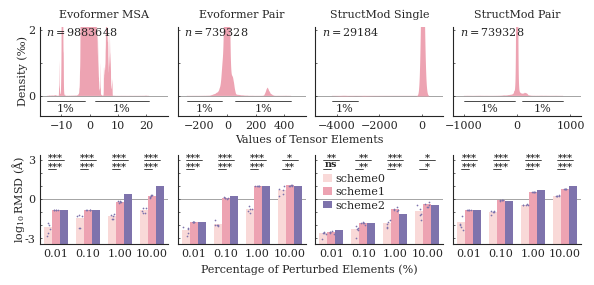

In [4]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  13/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1  *cm,
          'vsize':   9/4*cm,}

figsize = (figspec['lmargin'] + figspec['rmargin'] + figspec['hgap']*3 + figspec['hsize']*4, 
           figspec['bmargin'] + figspec['tmargin'] + figspec['vgap']*1 + figspec['vsize']*2, )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(2, 4, figsize=figsize, sharey="row", 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

# first row density.
for i_fig, i_mod in enumerate(mods.keys()):
  data = dens[i_mod]
  axes[0, i_fig].fill_between(data[0], data[1], color=bar_colors[1], lw=0.)
  axes[0, i_fig].plot((data[0].min(), data[0].max()), (0, 0), color=bar_colors[1], ls='-', lw=0.2, zorder=0)
  p0, p1, p99, p100 = np.percentile(get_latent(which_latent=i_mod), [0, 1, 99, 100])
  print(i_mod, p0, p100)
  axes[0, i_fig].plot((p0 , p1 ), (-0.00016, -0.00016), 'k-', lw=.5)
  axes[0, i_fig].text((p1+p0)/2 , -0.00025, '1%', ha='center', va='top', fontsize=8)
  if i_mod!='structmod_single':
    axes[0, i_fig].plot((p99 , p100), (-0.00016, -0.00016), 'k-', lw=.5)
    axes[0, i_fig].text((p99+p100)/2 , -0.00025, '1%', ha='center', va='top', fontsize=8)
  axes[0, i_fig].text(0.05, 0.9, f"$n={get_latent(i_mod).shape[0]}$", transform=axes[0, i_fig].transAxes, fontsize=8, ha='left')
  axes[0, i_fig].set(ylim=(-0.0006, 0.0021),
                     yticks=(0., 0.001, 0.002), 
                     yticklabels=('0', '', '2'), 
                     xlim=(-  17.5, 27.5) if i_mod=='evoformer_msa'    else \
                          (- 350  ,  550) if i_mod=='evoformer_pair'   else \
                          (-5000  , 1000) if i_mod=='structmod_single' else \
                          (-1200  , 1200) if i_mod=='structmod_pair'   else None, 
                     xticks=(- 10, 0,  10,  20) if i_mod=='evoformer_msa'     else \
                            (-200, 0, 200, 400) if i_mod=='evoformer_pair'    else \
                            (-4000, -2000,    0) if i_mod=='structmod_single' else \
                            (-1000,     0, 1000) if i_mod=='structmod_pair'   else None, )
  axes[0, i_fig].axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)
  axes[0, i_fig].set_title(mods[i_mod], fontsize=8, y=1.1, va='top')
axes[0, 0].set_ylabel('Density (‰)', fontsize=8, va='center')
axes[0, 0].set_xlabel('Values of Tensor Elements', fontsize=8, ha='center')
axes[0, 0].xaxis.set_label_coords((16+0.75)/2/16, 4/8, transform=fig.transFigure)

# second row perturb.
for i_fig, i_mod in enumerate(mods.keys()):
  data = pers[i_mod]; print(data)
  data_points = {'random2zero': np.vstack(tuple(data[f'random2zero_{_}'] for _ in range(5)))[:, [1,2,3,5]],
                 'resample':    np.vstack(tuple(data[f'resample_{_}'   ] for _ in range(5)))[:, [1,2,3,5]], }
  # bars.
  axes[1, i_fig].bar(np.arange(4)-0.25, data['random2zero'][[1,2,3,5]], width=0.25, lw=0., color=bar_colors[0], label='scheme0')
  axes[1, i_fig].bar(np.arange(4)     , data['resample'   ][[1,2,3,5]], width=0.25, lw=0., color=bar_colors[1], label='scheme1')
  axes[1, i_fig].bar(np.arange(4)+0.25, data['trim'       ][[1,2,3,5]], width=0.25, lw=0., color=bar_colors[2], label='scheme2')
  # points.
  for i_bar in range(4):
    axes[1, i_fig].scatter(i_bar+np.random.uniform(-0.08, 0.08, size=5)-0.25, data_points['random2zero'][:, i_bar], s=1.5, c="#7E73AC", lw=0.)
    axes[1, i_fig].scatter(i_bar+np.random.uniform(-0.08, 0.08, size=5)     , data_points['resample'   ][:, i_bar], s=1.5, c="#7E73AC", lw=0.)
  # stat sigs.
  for i_bar in range(4):
    _, pAB = scipy.stats.ttest_ind  (data_points['random2zero'][:, i_bar], data_points['resample'][:, i_bar], equal_var=True)
    _, pAC = scipy.stats.ttest_1samp(data_points['random2zero'][:, i_bar], data       ['trim'][[1,2,3,5]][i_bar])
    axes[1, i_fig].plot((i_bar-0.25, i_bar+0.25), (10**3  , 10**3  ), 'k-', lw=0.5)
    axes[1, i_fig].plot((i_bar-0.25, i_bar     ), (10**2.3, 10**2.3), 'k-', lw=0.5)
    axes[1, i_fig].text( i_bar, 10**(3. -(0.0 if get_stars(p_value=pAC)=='ns' else 0.15)), get_stars(p_value=pAC), ha='center', va='bottom', fontsize=7, fontweight='bold')
    axes[1, i_fig].text( i_bar, 10**(2.3-(0.0 if get_stars(p_value=pAB)=='ns' else 0.15)), get_stars(p_value=pAB), ha='center', va='bottom', fontsize=7, fontweight='bold')
  if i_fig==2:
    axes[1, i_fig].legend(loc='upper left', ncol=1,labelspacing=.3, columnspacing=1., handletextpad=0.3, prop={'size': 8}, handlelength=0.8, frameon=False, bbox_to_anchor=(-0.02, 0.9))
  axes[1, i_fig].set(yscale='log',
                     yticks=[10**_ for _ in range(-3, 4)],
                     yticklabels=['-3', '', '', '0', '', '', '3'],
                     ylim=(10**-3.4, 10**3.4),
                     xticks=[_ for _ in range(4)],
                     xticklabels=[f'{i:.2f}' for i in [0.01, 0.1, 1.0, 10.0]],
                     xlim=(-0.5, 3.5), )
  axes[1, i_fig].axhline(y=1, color='#808080', ls='-', lw=0.5, zorder=0)
axes[1, 0].set_ylabel('$\log_{10}$RMSD (Å)', fontsize=8, va='center')
axes[1, 0].set_xlabel('Percentage of Perturbed Elements (%)', fontsize=8, ha='center')
axes[1, 0].xaxis.set_label_coords((16+0.75)/2/16, 0.5/8, transform=fig.transFigure)

for _ in axes.flatten():
  _.minorticks_off()
  _.spines[['top','right']].set_visible(False)
  _.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
plt.savefig(f'./zfigures/fig_latent_ubq.jpg', dpi=300)